# 2.6 概率 (Probability)
> 对应教材《动手学深度学习》(PyTorch版) 第2.6节。  
> 严格提取教材中的抽样与大数定律模拟代码，并添加归属说明与注释。


In [1]:
# 【所属小节】2.6.1 基本概率论 - 导入必要软件包
# 【作用说明】导入PyTorch核心库、多项分布采样模块multinomial以及d2l画图与工具库
%matplotlib inline
import torch
from torch.distributions import multinomial
from d2l import torch as d2l


In [2]:
# 【所属小节】2.6.1 基本概率论 - 单次投掷骰子采样
# 【作用说明】构建均匀分布概率向量fair_probs(每个面概率为1/6)，并抽取1个样本(投掷1次骰子)
# 输出向量索引i处的值表示点数(i+1)出现的次数
fair_probs = torch.ones([6]) / 6
multinomial.Multinomial(1, fair_probs).sample()


tensor([1., 0., 0., 0., 0., 0.])

In [3]:
# 【所属小节】2.6.1 基本概率论 - 多次投掷骰子采样(批量采样)
# 【作用说明】利用深度学习框架的矢量化函数一次性抽取10个样本，模拟掷骰子10次，统计各点数出现频数
multinomial.Multinomial(10, fair_probs).sample()


tensor([2., 2., 1., 2., 1., 2.])

In [4]:
# 【所属小节】2.6.1 基本概率论 - 模拟1000次投掷并计算相对频率
# 【作用说明】投掷1000次骰子，将频数除以总次数1000，计算各面出现的相对频率作为真实概率的估计值(大数定律)
# 将结果存储为32位浮点数以进行除法
counts = multinomial.Multinomial(1000, fair_probs).sample()
counts / 1000  # 相对频率作为估计值


tensor([0.1570, 0.1750, 0.1850, 0.1710, 0.1530, 0.1590])

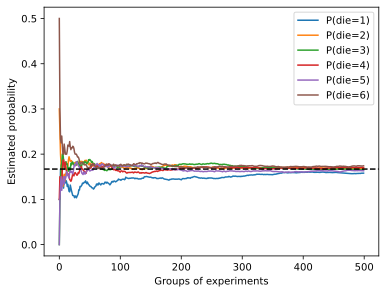

In [5]:
# 【所属小节】2.6.1 基本概率论 - 500组实验累积频率与收敛曲线可视化
# 【作用说明】进行500组实验，每组抽取10个样本；通过cumsum计算随实验组数递增的累积频数并求得累积概率估计值，
# 绘制6个面概率随实验组数增加向理论真实值1/6(约0.167)收敛的折线图。
counts = multinomial.Multinomial(10, fair_probs).sample((500,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)

d2l.set_figsize((6, 4.5))
for i in range(6):
    d2l.plt.plot(estimates[:, i].numpy(),
                 label=("P(die=" + str(i + 1) + ")"))
d2l.plt.axhline(y=0.167, color='black', linestyle='dashed')
d2l.plt.gca().set_xlabel('Groups of experiments')
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend();
